# 📏 Webinar 2 — Scaling y Métricas de Regresión
**Sprint 11 | Datasets: Titanic (clasificación) + California Housing (regresión)**

---
1. ¿Cuándo escalar y cuándo NO?
2. StandardScaler — qué hace por dentro
3. Otras opciones: MinMaxScaler, RobustScaler
4. Impacto real del scaling en un modelo
5. MAE, MSE, RMSE — intuición y diferencias
6. R² — qué significa de verdad
7. ¿Cómo mejorar las métricas en regresión?
---

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import  LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# ── Dataset 1: Titanic (para demostrar impacto del scaling en clasificación)
titanic = sns.load_dataset('titanic')[['survived','pclass','age','fare','alone']].dropna().copy()
titanic['alone'] = titanic['alone'].astype(int)

# ── Dataset 2: California Housing (para regresión)
housing_raw = fetch_california_housing(as_frame=True)
housing = housing_raw.frame.copy()

print("Titanic:", titanic.shape)
print("Housing:", housing.shape)
housing.head()

Titanic: (714, 5)
Housing: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Ver rangos de las features en Housing — aquí el scaling importa
housing.describe().T[['min','max','mean','std']].round(2)

,min,max,mean,std
MedInc,0.50,15.00,3.87,1.90
HouseAge,1.00,52.00,28.64,12.59
AveRooms,0.85,141.91,5.43,2.47
AveBedrms,0.33,34.07,1.10,0.47
Population,3.00,35682.00,1425.48,1132.46
AveOccup,0.69,1243.33,3.07,10.39
Latitude,32.54,41.95,35.63,2.14
Longitude,-124.35,-114.31,-119.57,2.00
MedHouseVal,0.15,5.00,2.07,1.15


---
## 1. ¿Cuándo escalar y cuándo NO?

El scaling pone todas las variables en la misma escala.  
**Problema:** `MedInc` va de 0 a 15, `AveRooms` de 0 a 140 — el modelo da más "peso" a la de mayor escala.

| Modelo | ¿Necesita scaling? | Razón |
|---|---|---|
| Regresión lineal / logística | ✅ Sí | Los coeficientes dependen de la escala |
| Árbol de decisión | ❌ No | Divide por umbrales, no por distancias |
| Random Forest / XGBoost | ❌ No | Basados en árboles |


In [25]:
# Demostración: KNN sin y con scaling — Titanic
X = titanic[['pclass','age','fare']]
y = titanic['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sin scaling
knn = LogisticRegression()
knn.fit(X_train, y_train)
acc_sin = accuracy_score(y_test, knn.predict(X_test))

# Con scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

knn_sc = LogisticRegression()
knn_sc.fit(X_train_sc, y_train)
acc_con = accuracy_score(y_test, knn_sc.predict(X_test_sc))

print(f"KNN sin scaling:  {acc_sin:.3f}")
print(f"KNN con scaling:  {acc_con:.3f}")
print(f"Mejora:          +{acc_con - acc_sin:.3f}")

KNN sin scaling:  0.671
KNN con scaling:  0.664
Mejora:          +-0.007


In [26]:
# Árbol de decisión — el scaling no cambia nada
tree_sin = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
tree_con = DecisionTreeClassifier(random_state=42).fit(X_train_sc, y_train)

print(f"Árbol sin scaling: {accuracy_score(y_test, tree_sin.predict(X_test)):.3f}")
print(f"Árbol con scaling: {accuracy_score(y_test, tree_con.predict(X_test_sc)):.3f}")
# → Mismo resultado, como esperábamos

Árbol sin scaling: 0.643
Árbol con scaling: 0.643


---
## 2. StandardScaler — qué hace por dentro

$$z = \frac{x - \mu}{\sigma}$$

- Centra en 0 (resta la media)
- Divide por la desviación estándar
- Resultado: **media = 0, std = 1**
- **No elimina outliers** — solo los comprime

In [27]:
# Ver la transformación en 'fare'
fare = titanic[['fare']]

ss = StandardScaler()
fare_scaled = ss.fit_transform(fare)

print(f"Original  — media: {fare['fare'].mean():.2f}  std: {fare['fare'].std():.2f}  min: {fare['fare'].min():.2f}  max: {fare['fare'].max():.2f}")
print(f"Scaled    — media: {fare_scaled.mean():.2f}  std: {fare_scaled.std():.2f}  min: {fare_scaled.min():.2f}  max: {fare_scaled.max():.2f}")
print(f"\nMedia aprendida por el scaler: {ss.mean_[0]:.2f}")
print(f"Std  aprendida por el scaler:  {ss.scale_[0]:.2f}")

Original  — media: 34.69  std: 52.92  min: 0.00  max: 512.33
Scaled    — media: -0.00  std: 1.00  min: -0.66  max: 9.03

Media aprendida por el scaler: 34.69
Std  aprendida por el scaler:  52.88


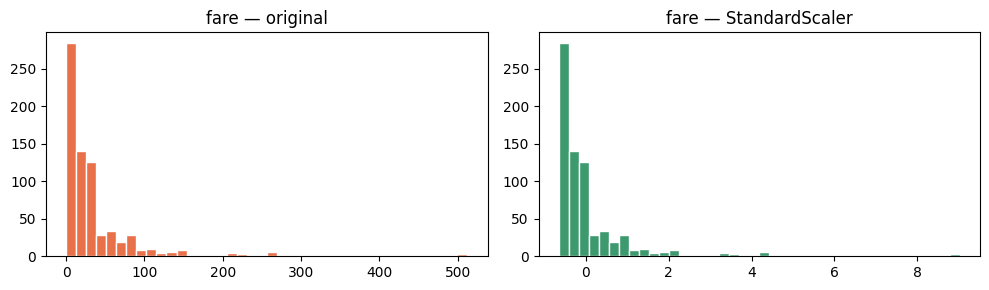

In [28]:
# Visualizar antes / después
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(fare['fare'], bins=40, color='#E8714A', edgecolor='white')
axes[0].set_title('fare — original')

axes[1].hist(fare_scaled, bins=40, color='#3D9A6E', edgecolor='white')
axes[1].set_title('fare — StandardScaler')

plt.tight_layout()
plt.show()
# La forma es idéntica — solo cambia la escala del eje X

---
## 3. Otras opciones: MinMaxScaler y RobustScaler

| Scaler | Fórmula | Rango resultado | Sensible a outliers |
|---|---|---|---|
| `StandardScaler` | (x − μ) / σ | Sin límite fijo | Moderadamente |
| `MinMaxScaler` | (x − min) / (max − min) | [0, 1] | ✅ Mucho |
| `RobustScaler` | (x − mediana) / IQR | Sin límite fijo | ❌ Poco |

In [29]:
# Comparar los tres sobre 'fare' (tiene outliers)
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}

for name, sc in scalers.items():
    vals = sc.fit_transform(fare)
    print(f"{name:18} → min: {vals.min():7.2f}  max: {vals.max():7.2f}  media: {vals.mean():.2f}  std: {vals.std():.2f}")

StandardScaler     → min:   -0.66  max:    9.03  media: -0.00  std: 1.00
MinMaxScaler       → min:    0.00  max:    1.00  media: 0.07  std: 0.10
RobustScaler       → min:   -0.62  max:   19.61  media: 0.75  std: 2.09


In [30]:
# Demostración del impacto de outliers en MinMaxScaler
# Un solo outlier puede comprimir todo el resto entre 0 y ~0.1
datos_con_outlier = pd.DataFrame({'x': [1, 2, 3, 4, 5, 500]})
datos_sin_outlier = pd.DataFrame({'x': [1, 2, 3, 4, 5]})

mm = MinMaxScaler()
print("Con outlier (500):")
print(mm.fit_transform(datos_con_outlier).T)

print("\nSin outlier:")
print(mm.fit_transform(datos_sin_outlier).T)

# → Con el outlier, los primeros 5 valores quedan todos < 0.01

Con outlier (500):
[[0.         0.00200401 0.00400802 0.00601202 0.00801603 1.        ]]

Sin outlier:
[[0.   0.25 0.5  0.75 1.  ]]


In [31]:
# RobustScaler ignora el outlier — usa mediana e IQR en lugar de media y std
rb = RobustScaler()
print("RobustScaler con outlier:")
print(rb.fit_transform(datos_con_outlier).T)
# → Los primeros 5 valores mantienen una distribución razonable

RobustScaler con outlier:
[[ -1.   -0.6  -0.2   0.2   0.6 198.6]]


**¿Cuándo usar cada uno?**
- `StandardScaler` → la mayoría de los casos, distribución sin muchos outliers
- `MinMaxScaler` → cuando necesitas valores en [0,1] (ej: redes neuronales, imágenes)
- `RobustScaler` → cuando hay outliers relevantes que no quieres eliminar


> ⚠️ **Nunca escales `y`** en clasificación.  
> En regresión, escalar `y` es posible pero complica la interpretación — evítalo salvo caso muy justificado.
> 
> El scaler va solo sobre **features `X`**, y siempre fit solo en **train**.

---
## 4. Métricas de regresión — intuición y diferencias

Primero entrenamos un modelo base para tener predicciones sobre las que medir.

In [33]:
# Modelo base: regresión lineal sobre California Housing
lr = LinearRegression()
lr.fit(X_train_hsc, y_train_h)
y_pred = lr.predict(X_test_hsc)

# Ver algunas predicciones vs reales
comparacion = pd.DataFrame({'real': y_test_h.values[:8], 'predicho': y_pred[:8].round(2)})
comparacion['error'] = (comparacion['real'] - comparacion['predicho']).round(2)
comparacion

,real,predicho,error
0,0.47700,0.72,-0.24
1,0.45800,1.76,-1.30
2,5.00001,2.71,2.29
3,2.18600,2.84,-0.65
4,2.78000,2.60,0.18
5,1.58700,2.01,-0.42
6,1.98200,2.65,-0.67
7,1.57500,2.17,-0.60


### MAE — Mean Absolute Error
$$MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|$$

- Promedio del **error absoluto**
- **Unidades:** las mismas que el target (USD, km, etc.)
- **Robusto** ante outliers — trata igual un error de 10 que uno de 100 (en términos relativos)
- Fácil de interpretar: "en promedio me equivoco en X unidades"

In [35]:
mae = mean_absolute_error(y_test_h, y_pred)
print(f"MAE: {mae:.4f}")
print(f"En promedio, el modelo se equivoca en ${mae * 100_000:,.0f} en el precio de una casa")
# El target está en cientos de miles de USD

MAE: 0.5332
En promedio, el modelo se equivoca en $53,320 en el precio de una casa


### MSE y RMSE — Mean Squared Error
$$MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 \qquad RMSE = \sqrt{MSE}$$

- **Penaliza más los errores grandes** (por el cuadrado)
- MSE está en unidades al cuadrado → difícil de interpretar
- RMSE vuelve a las unidades originales — más interpretable
- **Sensible a outliers** — un error de 10 pesa 100x más que uno de 1

In [34]:
mse  = mean_squared_error(y_test_h, y_pred)
rmse = np.sqrt(mse)

print(f"MSE:  {mse:.4f}  (en unidades²  — difícil de interpretar)")
print(f"RMSE: {rmse:.4f}  (en unidades   — comparable con MAE)")
print(f"\nMAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"\nRMSE > MAE siempre. Cuanto mayor la diferencia, más outliers de error hay.")

MSE:  0.5559  (en unidades²  — difícil de interpretar)
RMSE: 0.7456  (en unidades   — comparable con MAE)

MAE  = 0.4161
RMSE = 0.7456

RMSE > MAE siempre. Cuanto mayor la diferencia, más outliers de error hay.


In [36]:
# Intuición: efecto del cuadrado — un error grande pesa MUCHO más
errores     = np.array([0.5, 0.5, 0.5, 0.5, 5.0])  # un outlier
errores_mae = np.abs(errores).mean()
errores_mse = (errores**2).mean()
errores_rmse = np.sqrt(errores_mse)

print(f"Errores:    {errores}")
print(f"MAE:        {errores_mae:.3f}")
print(f"RMSE:       {errores_rmse:.3f}")
print(f"→ El outlier infla RMSE mucho más que MAE")

Errores:    [0.5 0.5 0.5 0.5 5. ]
MAE:        1.400
RMSE:       2.280
→ El outlier infla RMSE mucho más que MAE


### R² — Coeficiente de determinación

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- **Compara** tu modelo contra el modelo más simple posible: predecir siempre la media
- **R² = 1** → predicción perfecta
- **R² = 0** → igual de malo que predecir la media
- **R² < 0** → peor que predecir la media (modelo muy malo)
- No tiene unidades — comparable entre datasets

> ⚠️ R² **no** es "porcentaje de varianza explicada" en el sentido coloquial — es una razón de errores.

In [37]:
r2 = r2_score(y_test_h, y_pred)
print(f"R²: {r2:.4f}")

# Comparar contra baseline (predecir siempre la media)
y_baseline = np.full_like(y_test_h, y_train_h.mean())
r2_baseline = r2_score(y_test_h, y_baseline)
print(f"R² baseline (predecir media): {r2_baseline:.4f}")

R²: 0.5758
R² baseline (predecir media): -0.0002


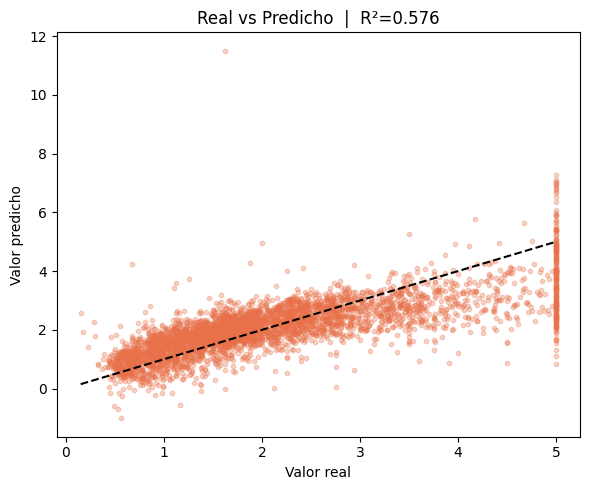

In [38]:
# Visualizar: real vs predicho — un buen R² = puntos cerca de la diagonal
plt.figure(figsize=(6, 5))
plt.scatter(y_test_h, y_pred, alpha=0.3, color='#E8714A', s=10)
plt.plot([y_test_h.min(), y_test_h.max()],
         [y_test_h.min(), y_test_h.max()], '--', color='black', lw=1.5)
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title(f'Real vs Predicho  |  R²={r2:.3f}')
plt.tight_layout()
plt.show()

---
## 6. ¿Cómo mejorar las métricas en regresión?

Cuando las métricas son malas, hay un checklist ordenado:

### 6a. Revisar los residuales

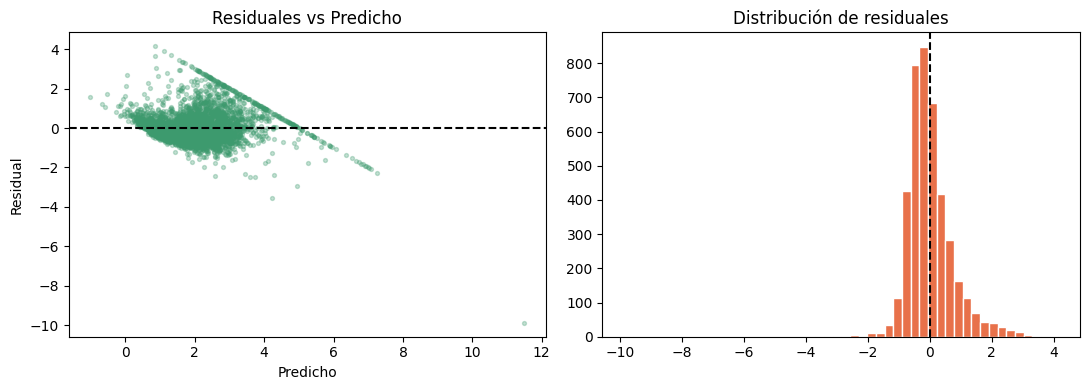

In [17]:
residuales = y_test_h.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Residual vs predicho — debe ser ruido aleatorio alrededor de 0
axes[0].scatter(y_pred, residuales, alpha=0.3, color='#3D9A6E', s=8)
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuales vs Predicho')

# Distribución de residuales — idealmente centrada en 0
axes[1].hist(residuales, bins=50, color='#E8714A', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Distribución de residuales')

plt.tight_layout()
plt.show()

# Si hay patrón en los residuales → el modelo está perdiendo estructura

### 6b. Transformaciones del target (log)

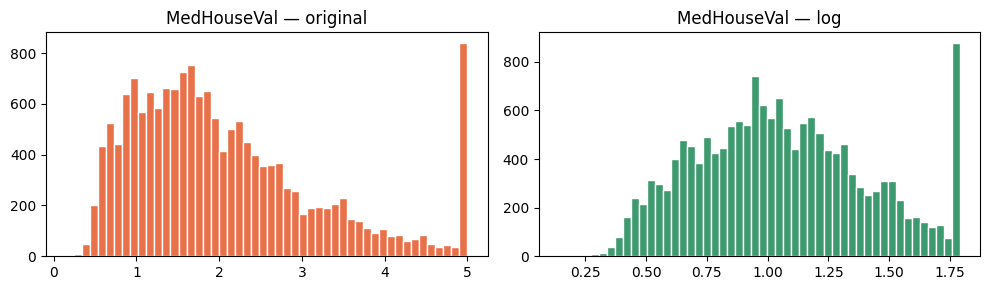

In [39]:
# Si el target tiene distribución muy sesgada, log puede ayudar
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(y_train_h, bins=50, color='#E8714A', edgecolor='white')
axes[0].set_title('MedHouseVal — original')
axes[1].hist(np.log1p(y_train_h), bins=50, color='#3D9A6E', edgecolor='white')
axes[1].set_title('MedHouseVal — log')
plt.tight_layout()
plt.show()

In [19]:
# Entrenar con log del target
y_train_log = np.log1p(y_train_h)

lr_log = LinearRegression()
lr_log.fit(X_train_hsc, y_train_log)

# Predicciones: deshacer el log con expm1
y_pred_log = np.expm1(lr_log.predict(X_test_hsc))

print(f"RMSE sin log:  {np.sqrt(mean_squared_error(y_test_h, y_pred)):.4f}")
print(f"RMSE con log:  {np.sqrt(mean_squared_error(y_test_h, y_pred_log)):.4f}")
print(f"R²  sin log:   {r2_score(y_test_h, y_pred):.4f}")
print(f"R²  con log:   {r2_score(y_test_h, y_pred_log):.4f}")

RMSE sin log:  0.7456
RMSE con log:  0.9809
R²  sin log:   0.5758
R²  con log:   0.2657


### 6d. Impacto de outliers en las métricas

In [40]:
# MAE vs RMSE ante outliers — demostración directa
# Creamos 2 conjuntos de predicciones: uno limpio, otro con un error enorme
np.random.seed(42)
y_real    = np.random.uniform(1, 5, 100)
y_pred_ok = y_real + np.random.normal(0, 0.3, 100)
y_pred_outlier = y_pred_ok.copy()
y_pred_outlier[0] = y_real[0] + 20  # un error enorme

for nombre, pred in [('Sin outlier', y_pred_ok), ('Con outlier', y_pred_outlier)]:
    mae  = mean_absolute_error(y_real, pred)
    rmse = np.sqrt(mean_squared_error(y_real, pred))
    print(f"{nombre}: MAE={mae:.3f}  RMSE={rmse:.3f}")

# → RMSE sube mucho más que MAE ante un solo outlier

Sin outlier: MAE=0.216  RMSE=0.273
Con outlier: MAE=0.416  RMSE=2.018


---
## 🏁 Resumen

**Scaling:**
| Scaler | Usar cuando |
|---|---|
| `StandardScaler` | Caso general, distribución razonablemente normal |
| `MinMaxScaler` | Necesitas rango [0,1], sin muchos outliers |
| `RobustScaler` | Hay outliers que no quieres eliminar |
| Sin scaler | Árboles, Random Forest, XGBoost |

**Métricas de regresión:**
| Métrica | Fortaleza | Debilidad |
|---|---|---|
| MAE | Interpretable, robusto | No penaliza errores grandes |
| RMSE | Penaliza errores grandes | Sensible a outliers |
| R² | Comparable entre datasets | No tiene unidades, puede engañar |

**Para mejorar métricas:**
1. Revisar residuales — ¿hay patrón?
2. Transformar el target si está muy sesgado (`log`)
3. Regularización (`Ridge` / `Lasso`)
4. Identificar y tratar outliers en features